In [2]:
import sys
project_path = "/home/aj/redesigned-octo-couscous" 
if project_path not in sys.path:
    sys.path.insert(0, project_path)

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

import dct

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(model_name, _attn_implementation="eager").to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left", truncation_side="left")
tokenizer.pad_token = tokenizer.eos_token

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [3]:
# source_layer, target_layer = 7, 13
source_layer, target_layer = 10, 20

sliced_model = dct.SlicedModel(model, source_layer, target_layer, layers_name="model.layers")

In [4]:
import pandas as pd

dataset = pd.read_csv(project_path + "/harmful_behaviors.csv")
instructions = dataset["target"].tolist()

_examples = instructions[:250]
# examples = _examples

chat_init = [{'content':"You are a helpful assistant", 'role':'system'}]
chats = [chat_init + [{'content': content, 'role':'user'}] for content in _examples]
examples = [tokenizer.apply_chat_template(chat, add_special_tokens=False, tokenize=False, add_generation_prompt=True) for chat in chats]

In [5]:
from tqdm.notebook import tqdm

d_model = model.config.hidden_size
n_samples = len(examples)
seq_len = 27
fwd_batch_size = 1

X = torch.zeros(n_samples, seq_len, d_model, device=device, dtype=model.dtype)
Y = torch.zeros(n_samples, seq_len, d_model, device=device, dtype=model.dtype)

for t in tqdm(range(0, n_samples, fwd_batch_size)):
    with torch.no_grad():
        model_inputs = tokenizer(examples[t:t+fwd_batch_size], return_tensors="pt", truncation=True, padding="max_length", max_length=seq_len).to(device)
        hidden_states = model(model_inputs["input_ids"], output_hidden_states=True).hidden_states
        h_source = hidden_states[source_layer] # b x t x d_model
        unsteered_target = sliced_model(h_source) # b x t x d_model

        X[t:t+fwd_batch_size, :, :] = h_source
        Y[t:t+fwd_batch_size, :, :] = unsteered_target

  0%|          | 0/250 [00:00<?, ?it/s]

In [6]:
from torch import vmap

factor_batch_size = 256

delta_acts_single = dct.DeltaActivations(sliced_model, slice(-3, None)).to(device)
delta_acts = vmap(delta_acts_single, in_dims=(1,None,None), out_dims=2,
                  chunk_size=factor_batch_size)

In [7]:
steering_calibrator = dct.SteeringCalibrator(target_ratio=.5)
input_scale = steering_calibrator.calibrate(delta_acts_single, X, Y, factor_batch_size=factor_batch_size)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [8]:
input_scale

9.466666698455356

In [9]:
X, Y = X.to(device), Y.to(device)

num_factors = 256
form = "exp"

if form == "lin":
    dct_ = dct.LinearDCT(num_factors=num_factors)
    U,V = dct_.fit(delta_acts_single, X, Y, input_scale=input_scale, factor_batch_size=factor_batch_size)

if form == "quad":
    dct_ = dct.QuadraticDCT(num_factors=num_factors)
    U,V = dct_.fit(delta_acts_single, X, Y, factor_batch_size=factor_batch_size)
    
if form == "exp":
    dct_ = dct.ExponentialDCT(num_factors=num_factors)
    U,V = dct_.fit(delta_acts_single, X, Y, input_scale=input_scale, factor_batch_size=factor_batch_size, init="random")

initializing V,U...
training...


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

In [10]:
# slice_to_end = dct.SlicedModel(
#     model,
#     start_layer=source_layer,
#     end_layer=model.config.num_hidden_layers,
#     apply_final_norm=True,
# )
# delta_acts_end_single = dct.DeltaActivations(slice_to_end)

# Y_end = torch.zeros_like(Y)
# with torch.no_grad():
#     for b in range(0, X.shape[0], fwd_batch_size):
#         Y_end[b:b+fwd_batch_size] = slice_to_end(X[b:b+fwd_batch_size])

# REFUSAL_TOKEN = tokenizer.encode("I", add_special_tokens=False)[0]
# SURE_TOKEN = tokenizer.encode("Sure", add_special_tokens=False)[0]
# with torch.no_grad():
#     target_vec = model.lm_head.weight.data[SURE_TOKEN,:] - model.lm_head.weight.data[REFUSAL_TOKEN,:]

# scores, indices = dct_.rank(delta_acts_end_single, X, Y_end, target_vec=target_vec,
#                             batch_size=fwd_batch_size, factor_batch_size=factor_batch_size)

# pd.DataFrame({"indices": indices.cpu().numpy(), "scores": scores.cpu().numpy()})

In [11]:
model_editor = dct.ModelEditor(model, layers_name="model.layers")

In [12]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import dct_attrib
importlib.reload(dct_attrib)
from dct_attrib import DCTAttrib

batch_size = 100000

attrib = DCTAttrib(V, U, device)

In [13]:
def plot_top_three_circuit_diversity():
    circuit_groups = []
    for target_factor in tqdm(range(U.shape[1]), desc="Attributing factors"):
        with torch.no_grad():
            top_circuits, _ = attrib.I(
                target_factor,
                width=3,
                k=3,
                batch_size=batch_size,
                input_scale=input_scale,
                silent=True,
            )
        circuits, _ = top_circuits.get()
        circuit_groups.append(circuits.cpu().numpy())

    num_groups = len(circuit_groups)
    diversity = np.zeros((num_groups, num_groups))
    for left in range(num_groups):
        for right in range(left + 1, num_groups):
            pairwise_distances = [
                1 - len(set(left_circuit) & set(right_circuit)) / len(
                    set(left_circuit) | set(right_circuit)
                )
                for left_circuit in circuit_groups[left]
                for right_circuit in circuit_groups[right]
            ]
            diversity[left, right] = diversity[right, left] = np.mean(pairwise_distances)

    total_pairwise_diversity = diversity[np.triu_indices(num_groups, k=1)].sum()

    fig, axis = plt.subplots(constrained_layout=True)
    image = axis.imshow(diversity, vmin=0, vmax=1)
    axis.set(
        xlabel="Other target factor",
        ylabel="Target factor",
    )
    fig.colorbar(image, ax=axis, label="Mean Jaccard distance")
    plt.show()

    return total_pairwise_diversity / (num_groups * (num_groups - 1) / 2)

# plot_top_three_circuit_diversity()

In [14]:
with torch.no_grad():
    top_circuits, _ = attrib.I(
        0,
        width=3,
        k=1,
        batch_size=batch_size,
        input_scale=1,
        silent=True,
    )
    circuit_indices, k = top_circuits.get()
print(circuit_indices, k)

tensor([[ 59, 127, 153]], device='cuda:0', dtype=torch.int16) tensor([1.8870])


In [ ]:
target_factor = 0
num_null_combinations = 100000

with torch.no_grad():
    top_circuits, _ = attrib.I(
        target_factor,
        width=3,
        k=1000,
        batch_size=batch_size,
        input_scale=input_scale,
        silent=True,
    )
    circuit_indices, _ = top_circuits.get()
    S = V[:, circuit_indices[1].long()].T
    null_vectors = torch.load(
        project_path + "/l10_vecs.pt",
        map_location="cpu",
        weights_only=True,
    )
    null_vectors = torch.nn.functional.normalize(null_vectors.float(), dim=1)
    z_result = attrib.combination_z_score(
        target_factor,
        S,
        null_vectors,
        num_combinations=num_null_combinations,
        input_scale=input_scale,
        batch_size=512,
    )

pd.Series({
    "target_factor": target_factor,
    "circuit": circuit_indices[1].cpu().tolist(),
    "sampled_combinations": z_result["num_combinations"],
    "possible_combinations": z_result["total_combinations"],
    "I_j(S)": z_result["observed"].item(),
    "mu_null": z_result["null_mean"].item(),
    "mu_null_mc_se": z_result["null_mean_se"].item(),
    "sigma_null": z_result["null_std"].item(),
    "z_score": z_result["z_score"].item(),
    "empirical_p_two_sided": z_result["empirical_p_two_sided"].item(),
})

tensor(1.1086e+09)
tensor(1.3079)


target_factor                         0
circuit                  [59, 105, 176]
sampled_combinations             100000
possible_combinations      309162151936
I_j(S)                     1108557184.0
mu_null                        0.084411
mu_null_mc_se                   0.00027
sigma_null                     0.085508
z_score                   12964440064.0
empirical_p_two_sided           0.00001
dtype: object

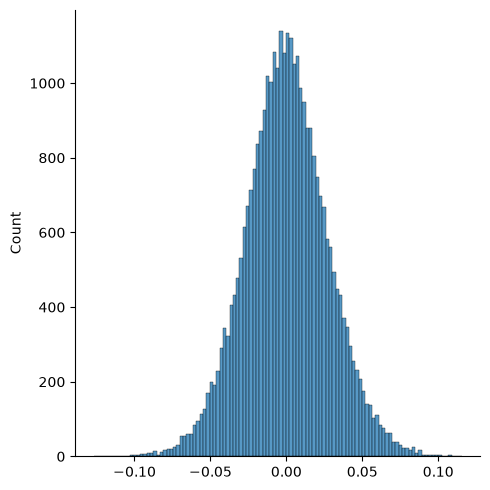

In [52]:
with torch.no_grad():
    simu = (null_vectors[:len(V)].T @ V.cpu())
    simu = simu[torch.triu(torch.ones_like(simu), diagonal=1).bool()]
import seaborn as sns
sns.displot(simu.cpu())

In [16]:
# top_index = 245
# model_editor.steer(V[:, top_index], source_layer - 1)

# def get_circuit(i):
#     s, _ = top_k.get()
#     g = s.cpu().tolist()[i]
#     print(g)
#     return torch.stack([V[:,x] for x in g]).mean(dim=0)

# model_editor.restore()
# model_editor.steer(input_scale*get_circuit(0), source_layer-1)

# generated_ids = model.generate(**model_inputs, max_new_tokens=30, do_sample=False)
# completion = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

# print(repr(completion))

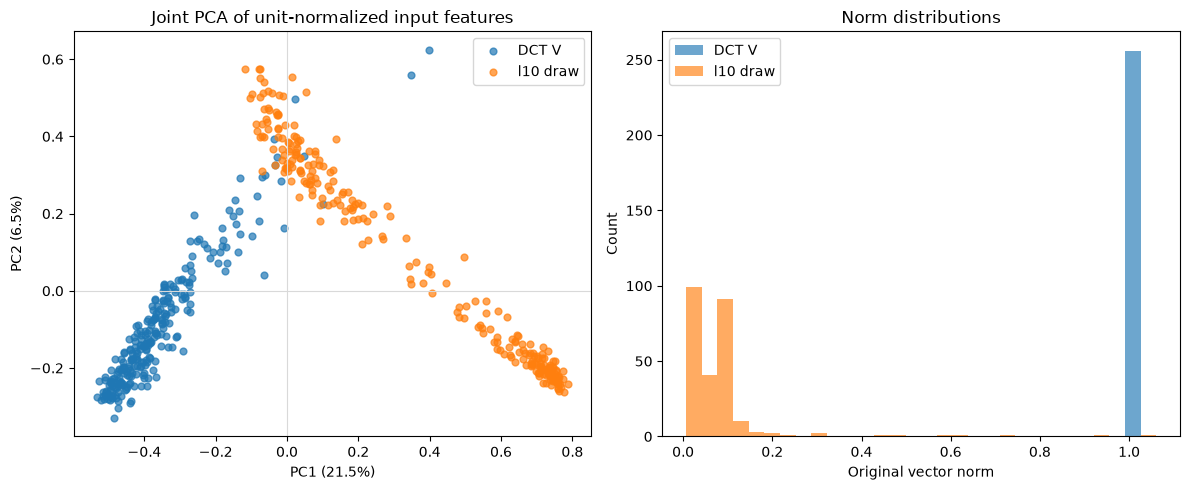

{'V_shape': (256, 1536), 'l10_pool_shape': (12288, 1536), 'explained_variance_PC1_PC2': [0.21485495567321777, 0.06501396745443344], 'V_norm_mean_std': (1.0, 2.651451325164089e-07), 'l10_norm_mean_std': (0.08428415656089783, 0.11536253988742828)}


In [34]:
import matplotlib.pyplot as plt

# Compare DCT input directions with an equally sized crosscoder decoder sample.
v_features = V.detach().float().T.cpu()
l10_vectors = torch.load(project_path + "/l10_vecs.pt", map_location="cpu").detach().float().squeeze()
if l10_vectors.ndim != 2:
    raise ValueError(f"Expected a decoder matrix, got shape {tuple(l10_vectors.shape)}")
if l10_vectors.shape[1] != v_features.shape[1]:
    if l10_vectors.shape[0] == v_features.shape[1]:
        l10_vectors = l10_vectors.T
    else:
        raise ValueError(
            f"Neither l10_vecs axis matches V dimension {v_features.shape[1]}: "
            f"got {tuple(l10_vectors.shape)}"
        )
if l10_vectors.shape[0] < v_features.shape[0]:
    raise ValueError("l10_vecs contains fewer vectors than V")

generator = torch.Generator().manual_seed(0)
sample_indices = torch.randperm(l10_vectors.shape[0], generator=generator)[:v_features.shape[0]]
l10_sample = l10_vectors[sample_indices]

v_norms = v_features.norm(dim=1)
l10_norms = l10_sample.norm(dim=1)
v_unit = torch.nn.functional.normalize(v_features, dim=1)
l10_unit = torch.nn.functional.normalize(l10_sample, dim=1)
combined = torch.cat((v_unit, l10_unit), dim=0)
combined_centered = combined - combined.mean(dim=0, keepdim=True)
_, singular_values, principal_axes = torch.pca_lowrank(combined_centered, q=2, center=False)
coordinates = combined_centered @ principal_axes
v_coordinates = coordinates[:v_features.shape[0]]
l10_coordinates = coordinates[v_features.shape[0]:]
explained = singular_values.square() / combined_centered.square().sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(v_coordinates[:, 0], v_coordinates[:, 1], s=24, alpha=0.7, label="DCT V")
axes[0].scatter(l10_coordinates[:, 0], l10_coordinates[:, 1], s=24, alpha=0.7, label="l10 draw")
axes[0].set(
    xlabel=f"PC1 ({explained[0]:.1%})",
    ylabel=f"PC2 ({explained[1]:.1%})",
    title="Joint PCA of unit-normalized input features",
)
axes[0].axhline(0, color="0.85", linewidth=0.8)
axes[0].axvline(0, color="0.85", linewidth=0.8)
axes[0].legend()

all_norms = torch.cat((v_norms, l10_norms)).double()
norm_min, norm_max = all_norms.min().item(), all_norms.max().item()
norm_padding = max((norm_max - norm_min) * 0.02, abs(norm_min) * 1e-6, 1e-8)
norm_bins = torch.linspace(norm_min - norm_padding, norm_max + norm_padding, 31, dtype=torch.float64).numpy()
axes[1].hist(v_norms.double().numpy(), bins=norm_bins, alpha=0.65, label="DCT V")
axes[1].hist(l10_norms.double().numpy(), bins=norm_bins, alpha=0.65, label="l10 draw")
axes[1].set(xlabel="Original vector norm", ylabel="Count", title="Norm distributions")
axes[1].legend()
plt.tight_layout()
plt.show()

print({
    "V_shape": tuple(v_features.shape),
    "l10_pool_shape": tuple(l10_vectors.shape),
    "explained_variance_PC1_PC2": explained.tolist(),
    "V_norm_mean_std": (v_norms.mean().item(), v_norms.std().item()),
    "l10_norm_mean_std": (l10_norms.mean().item(), l10_norms.std().item()),
})

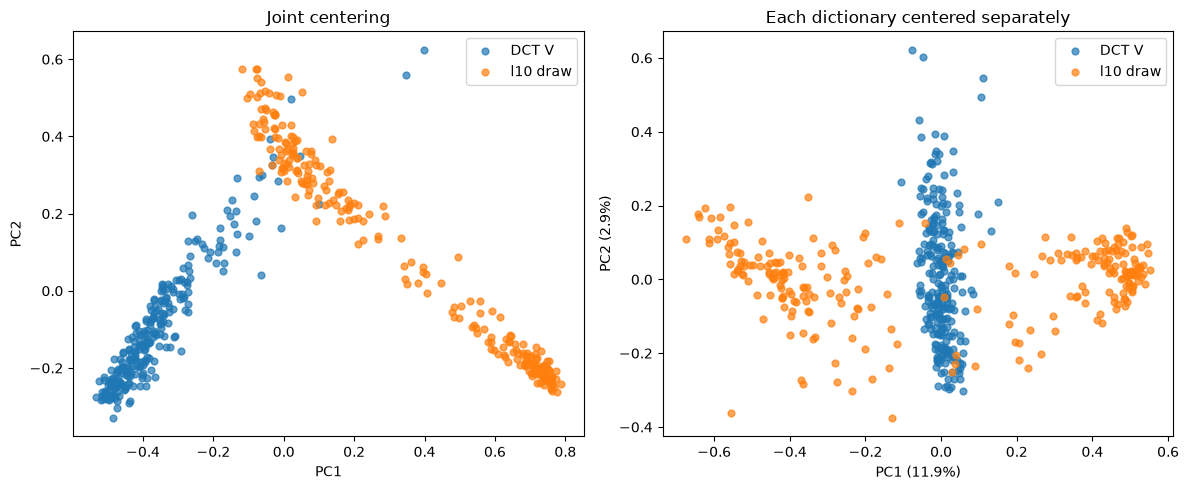

{'abs_cosine_PC1_vs_mean_difference': 0.9672252535820007, 'PC1_variance_from_group_means': 0.6742680668830872, 'total_variance_from_group_means': 0.15485423803329468, 'joint_PC1_group_means': [-0.3567013740539551, 0.3567013144493103], 'within_centered_PC1_PC2_explained': [0.11885404586791992, 0.02878778986632824]}


In [36]:
# Test whether joint PC1 is mainly separating the two dictionary means.
v_mean = v_unit.mean(dim=0, keepdim=True)
l10_mean = l10_unit.mean(dim=0, keepdim=True)
mean_difference = (l10_mean - v_mean).squeeze(0)
mean_difference_unit = torch.nn.functional.normalize(mean_difference, dim=0)
pc1 = principal_axes[:, 0]
pc1_mean_alignment = torch.dot(pc1, mean_difference_unit).abs()

joint_scores_pc1 = combined_centered @ pc1
group_mean_scores_pc1 = torch.stack((
    joint_scores_pc1[:len(v_unit)].mean(),
    joint_scores_pc1[len(v_unit):].mean(),
))
grand_mean_pc1 = joint_scores_pc1.mean()
between_sum_squares_pc1 = len(v_unit) * (group_mean_scores_pc1[0] - grand_mean_pc1).square()
between_sum_squares_pc1 += len(l10_unit) * (group_mean_scores_pc1[1] - grand_mean_pc1).square()
pc1_between_fraction = between_sum_squares_pc1 / joint_scores_pc1.square().sum()

# Decompose total high-dimensional variance into between- and within-dictionary parts.
v_within_centered = v_unit - v_mean
l10_within_centered = l10_unit - l10_mean
within_centered = torch.cat((v_within_centered, l10_within_centered), dim=0)
total_between_fraction = 1 - within_centered.square().sum() / combined_centered.square().sum()

# Refit PCA only after removing each dictionary's own mean.
_, within_singular_values, within_axes = torch.pca_lowrank(within_centered, q=2, center=False)
within_coordinates = within_centered @ within_axes
v_within_coordinates = within_coordinates[:len(v_unit)]
l10_within_coordinates = within_coordinates[len(v_unit):]
within_explained = within_singular_values.square() / within_centered.square().sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(v_coordinates[:, 0], v_coordinates[:, 1], s=24, alpha=0.7, label="DCT V")
axes[0].scatter(l10_coordinates[:, 0], l10_coordinates[:, 1], s=24, alpha=0.7, label="l10 draw")
axes[0].set(title="Joint centering", xlabel="PC1", ylabel="PC2")
axes[0].legend()

axes[1].scatter(v_within_coordinates[:, 0], v_within_coordinates[:, 1], s=24, alpha=0.7, label="DCT V")
axes[1].scatter(l10_within_coordinates[:, 0], l10_within_coordinates[:, 1], s=24, alpha=0.7, label="l10 draw")
axes[1].set(
    title="Each dictionary centered separately",
    xlabel=f"PC1 ({within_explained[0]:.1%})",
    ylabel=f"PC2 ({within_explained[1]:.1%})",
)
axes[1].legend()
plt.tight_layout()
plt.show()

print({
    "abs_cosine_PC1_vs_mean_difference": pc1_mean_alignment.item(),
    "PC1_variance_from_group_means": pc1_between_fraction.item(),
    "total_variance_from_group_means": total_between_fraction.item(),
    "joint_PC1_group_means": group_mean_scores_pc1.tolist(),
    "within_centered_PC1_PC2_explained": within_explained.tolist(),
})